# Tech Challenge 1



# 1. Entendimento de negócio**

<div style="text-align: justify;">
O **Net Promoter Score (NPS)** é um indicador utilizado para avaliar a satisfação e a lealdade dos clientes a partir da probabilidade de recomendarem uma empresa, produto ou serviço. Além de acompanhar a percepção geral dos consumidores, o NPS pode ser utilizado como ponto de partida para identificar problemas ao longo da jornada do cliente.

</div>

<br>

<div style="text-align: justify;">

**Classificação do NPS**  
A avaliação do NPS divide os clientes em três grupos de acordo com a nota atribuída:  
**1:** Detratores (0 a 6): clientes insatisfeitos, com maior possibilidade de compartilhar experiências negativas e menor propensão à recomendação.  
**2:** Neutros/Passivos (7 e 8): clientes satisfeitos, porém sem forte vínculo ou propensão à recomendação.  
**3:** Promotores (9 e 10): clientes altamente satisfeitos e mais propensos a recomendar a empresa.  

</div>

<br>

O indicador é calculado pela diferença entre o percentual de promotores e o percentual de detratores:  

<div align="center">
**NPS = % Promotores − % Detratores**
</div>

<br>

<div style="text-align: justify;">

Neste projeto, o objetivo é ir além do valor do indicador e entender quais fatores da experiência estão relacionados à satisfação dos clientes e, principalmente, à geração de detratores. Para isso, serão analisadas diferentes características da jornada de compra, buscando identificar padrões, pontos críticos e possíveis causas de insatisfação.
Problema de negócio

</div>

<br>

<div style="text-align: justify;">

**O principal problema a ser respondido é:**

**Quais fatores da jornada do cliente mais impactam sua satisfação e contribuem para que ele se torne um detrator?**

A partir dessa pergunta, a análise buscará **identificar** os principais pontos de atrito na experiência e possíveis **pontos de ruptura**, ou seja, situações em que determinada variável passa a apresentar um **impacto relevante na satisfação do cliente**.

</div>

## Importância para o negócio


<div style="text-align: justify;">

Para um e-commerce, compreender esses fatores é especialmente importante, pois a experiência do cliente envolve diferentes etapas, como preço, compra, entrega, qualidade do produto, atendimento e resolução de problemas.
Identificar quais dessas etapas estão mais relacionadas à insatisfação permite transformar o NPS de um simples indicador de acompanhamento em uma ferramenta de diagnóstico e tomada de decisão.

<br>

Os resultados podem apoiar áreas como Logística, Atendimento, Customer Experience, Pricing, Produto e Marketing/CRM, ajudando na priorização de iniciativas voltadas à melhoria da experiência, redução de detratores e aumento da satisfação e fidelização dos clientes.

</div>

# Objetivos da análise
Com base no problema de negócio apresentado, a análise exploratória será conduzida buscando responder principalmente:
<br>
- Quais fatores parecem mais críticos para a satisfação dos clientes?
- Quais características estão mais associadas à geração de detratores?
- Existe algum ponto de ruptura na experiência do cliente?

# EDA - Análise exploratório de dados

### Instalando as bibliotecas necessárias para a EDA

In [6]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn

# Importação das bibliotecas

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('desafio_nps_fase_1.csv')

In [9]:
df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7


### Tamanho da base de dados

In [10]:
df.shape

(2500, 19)

### Verificando o tipo dos dados e dados nulos

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

# 1.1 Estatisticas descritivas

### Análise:
**Análise descritiva inicial**

<br>

A base analisada possui 2.500 registros e não apresenta valores ausentes nas variáveis numéricas avaliadas pelo describe().

<br>

A análise inicial indica alguns pontos que merecem aprofundamento durante a EDA. A nota média de NPS é de 4,38, enquanto o CSAT interno apresenta média de 2,94, indicando inicialmente níveis baixos de satisfação. Além disso, aproximadamente 9% dos registros apresentam recompra em até 30 dias.

<br>

Em relação à experiência operacional, o tempo médio de entrega é de 8,02 dias, com atraso médio de 2,19 dias. Já no atendimento, os clientes realizam em média 1,52 contatos, enquanto o tempo médio para resolução é de 5,49 dias. A quantidade média de reclamações é de 4,15 por registro.

<br>

Esses resultados não permitem, isoladamente, determinar quais fatores são responsáveis pela satisfação ou insatisfação dos clientes. Entretanto, levantam hipóteses importantes para a análise exploratória, principalmente relacionadas a atrasos na entrega, reclamações, contatos com o atendimento e tempo de resolução.

<br>

Nas próximas etapas, essas variáveis serão relacionadas ao NPS com o objetivo de identificar quais fatores apresentam maior associação com a geração de detratores e se existem pontos de ruptura na experiência do cliente.

In [12]:
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


# 2.1 Qual é a distribuição dos clientes entre detratores, neutros e promotores?

**Análise**

<br>

O primeiro cenário observado é bastante crítico: 84,36% dos clientes são classificados como detratores, enquanto apenas 4,40% são promotores e 11,24% são neutros.

<br>

A partir dessa distribuição, o NPS da base é de aproximadamente -80, indicando um forte desequilíbrio entre clientes insatisfeitos e clientes dispostos a recomendar a empresa.

<br>

Esse resultado evidencia a existência de uma experiência predominantemente negativa entre os clientes analisados. Entretanto, a distribuição do NPS isoladamente não permite identificar quais fatores estão associados a essa insatisfação.

<br>

A partir desse diagnóstico inicial, a análise será aprofundada para entender quais aspectos da jornada apresentam maior relação com a geração de detratores, considerando principalmente fatores relacionados à logística, atendimento, reclamações e experiência de compra.

In [13]:
def classificador_nps(df):
    if df['nps_score']>=9:
        return 'Promotores'
    elif df['nps_score']>=7:
        return 'Neutro'
    else:
        return 'Detrator'

In [14]:
df['clas_cliente'] = df.apply(classificador_nps, axis=1)

In [15]:
df[['clas_cliente', 'nps_score']].head(10)

,clas_cliente,nps_score
0,Detrator,6.9
1,Detrator,2.4
2,Detrator,4.8
3,Detrator,5.9
4,Detrator,6.1
5,Detrator,0.9
6,Detrator,1.4
7,Detrator,0.0
8,Detrator,6.2
9,Detrator,2.7


In [16]:
prop_clientes = df['clas_cliente'].value_counts()/len(df)*100

In [17]:
prop_clientes

,count
clas_cliente,
Detrator,84.36
Neutro,11.24
Promotores,4.40


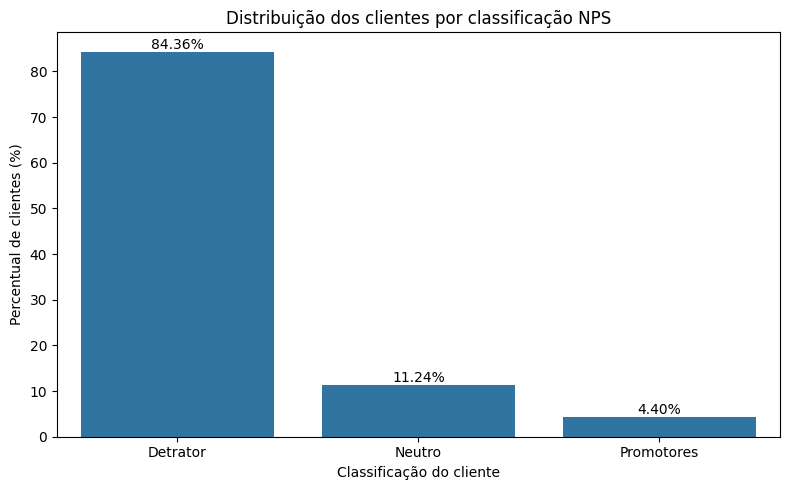

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
  data = (
    df['clas_cliente']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name='percentual')
  ),
  x = 'clas_cliente',
  y='percentual',
  ax=ax
)


ax.set_title('Distribuição dos clientes por classificação NPS')
ax.set_xlabel('Classificação do cliente')
ax.set_ylabel('Percentual de clientes (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.show()

# 2.2 One-Hot Encoding da classificação NPS para entender a relação dos tipos de clientes com as demais variaveis

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
# Instanciando o encoder
encoder = OneHotEncoder(
    sparse_output=False,
    dtype=int
)

In [21]:
# Aplicando One-Hot Encoding
encoded = encoder.fit_transform(df[['clas_cliente','customer_region']])

In [22]:
encoded

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 0]])

In [23]:
encoder.get_feature_names_out()

array(['clas_cliente_Detrator', 'clas_cliente_Neutro',
       'clas_cliente_Promotores', 'customer_region_Centro-Oeste',
       'customer_region_Nordeste', 'customer_region_Norte',
       'customer_region_Sudeste', 'customer_region_Sul'], dtype=object)

In [24]:
# Transformando o resultado em DataFrame
df_encoded = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(),
    index=df.index
)

In [25]:
# Remove as colunas do encoding caso já existam
df = df.drop(
    columns=df_encoded.columns,
    errors='ignore'
)


# Adicionando as novas variáveis ao dataset
df = pd.concat(
    [df, df_encoded],
    axis=1
)

In [26]:
df.head(5)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,csat_internal_score,clas_cliente,clas_cliente_Detrator,clas_cliente_Neutro,clas_cliente_Promotores,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,6.5,Detrator,1,0,0,0,1,0,0,0
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,0.0,Detrator,1,0,0,0,0,0,0,1
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,1.5,Detrator,1,0,0,0,1,0,0,0
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,0.3,Detrator,1,0,0,1,0,0,0,0
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,7.9,Detrator,1,0,0,0,0,1,0,0


In [27]:
df.columns

Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score',
       'clas_cliente', 'clas_cliente_Detrator', 'clas_cliente_Neutro',
       'clas_cliente_Promotores', 'customer_region_Centro-Oeste',
       'customer_region_Nordeste', 'customer_region_Norte',
       'customer_region_Sudeste', 'customer_region_Sul'],
      dtype='object')

In [28]:
df_corr_clas_cliente = df.corr(numeric_only=True)[['clas_cliente_Detrator', 'clas_cliente_Neutro',
       'clas_cliente_Promotores']]

In [29]:
df_corr_clas_cliente = df_corr_clas_cliente[
    df_corr_clas_cliente.abs().max(axis=1) >= 0.10
]

In [30]:
df_corr_clas_cliente = df_corr_clas_cliente.drop(
    index=[
        'nps_score',
        'clas_cliente_Detrator',
        'clas_cliente_Neutro',
        'clas_cliente_Promotores'
    ],
    errors='ignore'
)

**Análise:**
<br>
A matriz de correlação evidencia que os fatores operacionais com maior associação positiva à classificação de detratores são o número de reclamações (0,38) e os dias de atraso na entrega (0,36). O número de contatos com o atendimento (0,21) e o tempo de resolução (0,14) também apresentam associação positiva, embora de menor intensidade.
<br>
Em sentido contrário, o CSAT interno apresenta correlação negativa com detratores (-0,40) e positiva com neutros e promotores, demonstrando consistência entre os indicadores de satisfação.
<br>
A recompra em até 30 dias apresenta uma das relações mais fortes da análise, sendo negativamente associada aos detratores (-0,72) e positivamente associada aos promotores (0,69). Esse resultado sugere uma relação relevante entre satisfação e comportamento de recompra.
<br>
A partir desses resultados, atrasos na entrega e reclamações serão aprofundados como potenciais pontos de atrito da jornada, buscando identificar possíveis pontos de ruptura na experiência do cliente.

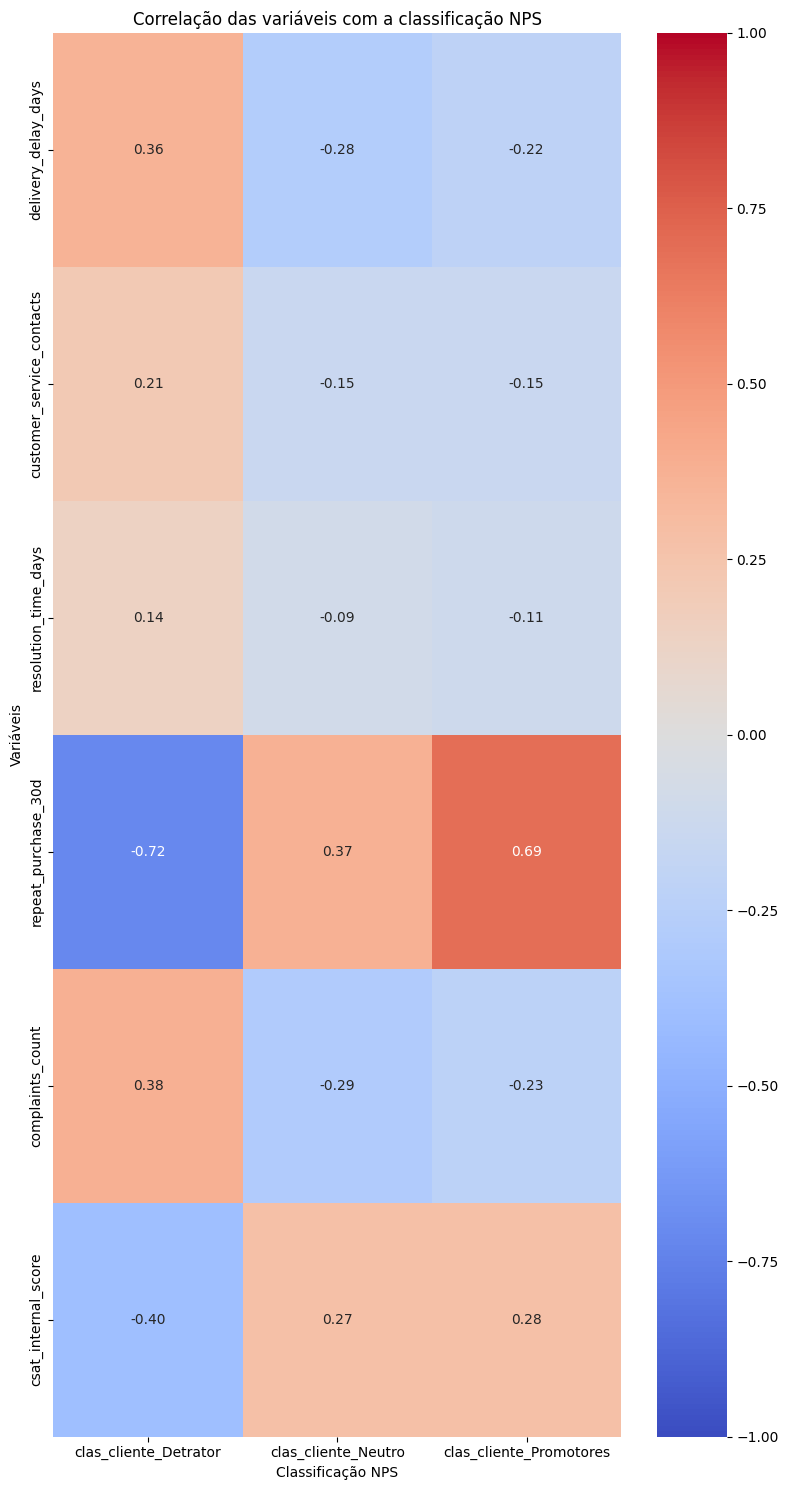

In [31]:
plt.figure(figsize=(8, 15))

sns.heatmap(
    df_corr_clas_cliente,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlação das variáveis com a classificação NPS")
plt.xlabel("Classificação NPS")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()

# 2.3 Em que momento o atraso passa a aumentar significativamente a proporção de detratores? (Ponto de Ruptura)

A análise inicial da distribuição dos dias de atraso mostrou comportamentos distintos entre **detratores, neutros e promotores**.

Como a base apresenta uma proporção significativamente maior de detratores, a comparação por valores absolutos poderia gerar uma interpretação enviesada. Por esse motivo, a distribuição foi **normalizada dentro de cada classificação NPS**, permitindo comparar o comportamento dos grupos independentemente de seus diferentes tamanhos.

### Análise dos resultados

Os resultados mostram uma diferença clara no comportamento dos clientes em relação ao atraso:

- **Promotores:** **85,5%** tiveram atraso de **até 1 dia**.
- **Neutros:** **71,2%** tiveram atraso de **até 1 dia**.
- **Detratores:** apenas **28,4%** tiveram atraso de até 1 dia, enquanto **71,6%** apresentaram atraso de **2 dias ou mais**.

Dessa forma, observa-se uma **inversão no comportamento dos detratores**. Enquanto neutros e promotores estão predominantemente concentrados em atrasos de até 1 dia, a maior parte dos detratores está concentrada em atrasos iguais ou superiores a 2 dias.

### Ponto de ruptura

Os resultados sugerem que **2 dias de atraso representam um possível ponto de ruptura na experiência do cliente**, uma vez que, a partir desse patamar, observa-se uma concentração significativamente maior de clientes detratores.

### Impacto para o negócio

Do ponto de vista de negócio, o resultado indica que o acompanhamento logístico não deve considerar apenas a existência de atraso, mas também sua **magnitude**.

Manter os atrasos **abaixo de 2 dias** pode representar um limite operacional relevante para a experiência do cliente. Pedidos próximos ou acima desse limite poderiam ser priorizados para ações como **comunicação proativa com o cliente, acompanhamento logístico e recuperação de serviço**.

> **Conclusão:** a análise exploratória aponta **2 dias de atraso como o principal candidato a ponto de ruptura da experiência de entrega**. Entretanto, o resultado representa uma **associação observada nos dados**, não sendo suficiente, isoladamente, para estabelecer uma relação de causalidade.

In [32]:
df_detratores = df[df['clas_cliente'] == 'Detrator']
df_neutros = df[df['clas_cliente'] == 'Neutro']
df_promotores = df[df['clas_cliente'] == 'Promotores']

contagem_detratores = (
    df_detratores['delivery_delay_days']
    .value_counts()
    .sort_index()
)

contagem_neutros = (
    df_neutros['delivery_delay_days']
    .value_counts()
    .sort_index()
)

contagem_promotores = (
    df_promotores['delivery_delay_days']
    .value_counts()
    .sort_index()
)

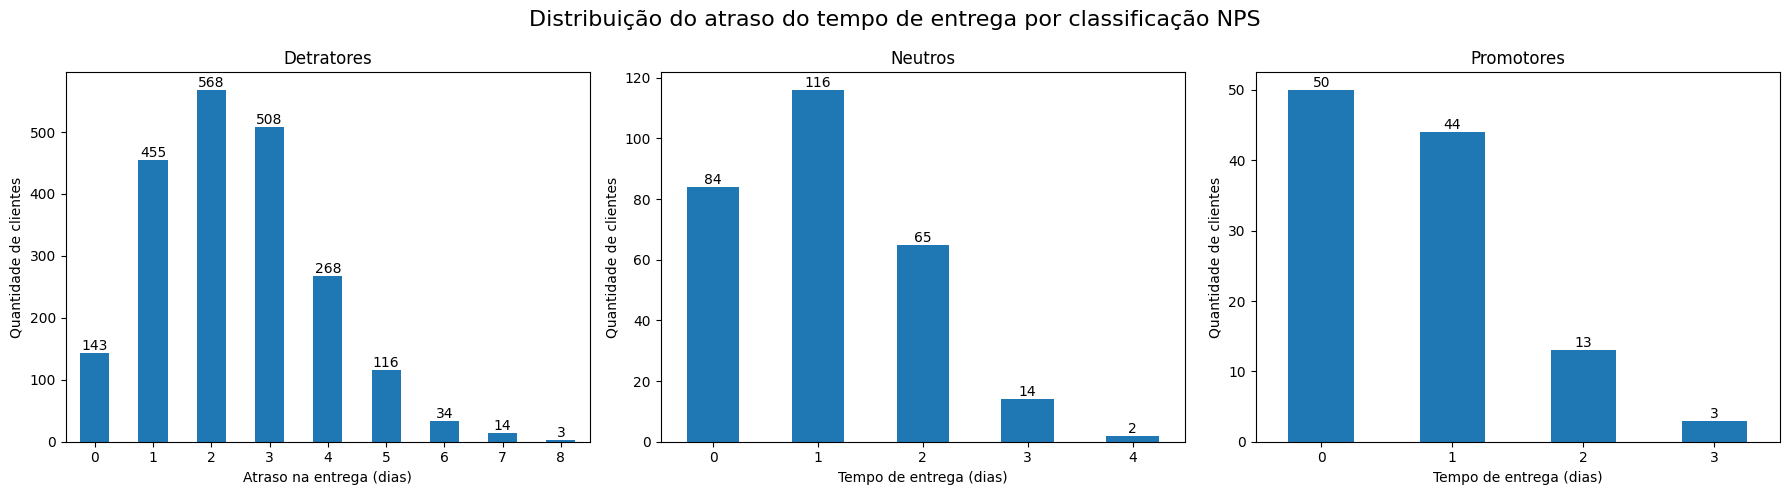

In [33]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Detratores
contagem_detratores.plot(
    kind='bar',
    ax=axs[0]
)

axs[0].set_title('Detratores')
axs[0].set_xlabel('Atraso na entrega (dias)')
axs[0].set_ylabel('Quantidade de clientes')
axs[0].tick_params(axis='x', rotation=0)

# Rótulos nas barras
for container in axs[0].containers:
    axs[0].bar_label(container, fmt='%.0f')


# Neutros
contagem_neutros.plot(
    kind='bar',
    ax=axs[1]
)

axs[1].set_title('Neutros')
axs[1].set_xlabel('Tempo de entrega (dias)')
axs[1].set_ylabel('Quantidade de clientes')
axs[1].tick_params(axis='x', rotation=0)

for container in axs[1].containers:
    axs[1].bar_label(container, fmt='%.0f')


# Promotores
contagem_promotores.plot(
    kind='bar',
    ax=axs[2]
)

axs[2].set_title('Promotores')
axs[2].set_xlabel('Tempo de entrega (dias)')
axs[2].set_ylabel('Quantidade de clientes')
axs[2].tick_params(axis='x', rotation=0)

for container in axs[2].containers:
    axs[2].bar_label(container, fmt='%.0f')


fig.suptitle(
    'Distribuição do atraso do tempo de entrega por classificação NPS',
    fontsize=16
)

plt.tight_layout()
plt.show()

**Insight:**
A distribuição dos dias de atraso apresenta uma mudança clara entre as classificações NPS. Enquanto 85,5% dos promotores e 71,2% dos clientes neutros estão concentrados em entregas com até 1 dia de atraso, 71,6% dos detratores apresentam atrasos iguais ou superiores a 2 dias. Esse comportamento sugere que a partir de 2 dias de atraso pode existir um ponto de ruptura relevante na experiência do cliente, aumentando sua associação com a condição de detrator.

In [34]:
distrib_atraso = pd.crosstab(
    df['delivery_delay_days'],
    df['clas_cliente'],
    normalize='columns'
).mul(100).round(1)

distrib_atraso

clas_cliente,Detrator,Neutro,Promotores
delivery_delay_days,,,
0,6.8,29.9,45.5
1,21.6,41.3,40.0
2,26.9,23.1,11.8
3,24.1,5.0,2.7
4,12.7,0.7,0.0
5,5.5,0.0,0.0
6,1.6,0.0,0.0
7,0.7,0.0,0.0
8,0.1,0.0,0.0


In [35]:
df['faixa_atraso'] = df['delivery_delay_days'].apply(
    lambda x: 'Até 1 dia' if x <= 1 else '2 dias ou mais'
)

In [36]:
contagem_detratores = (
    df[df['clas_cliente'] == 'Detrator']['faixa_atraso']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(['Até 1 dia', '2 dias ou mais'])
)

contagem_neutros = (
    df[df['clas_cliente'] == 'Neutro']['faixa_atraso']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(['Até 1 dia', '2 dias ou mais'])
)

contagem_promotores = (
    df[df['clas_cliente'] == 'Promotores']['faixa_atraso']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(['Até 1 dia', '2 dias ou mais'])
)

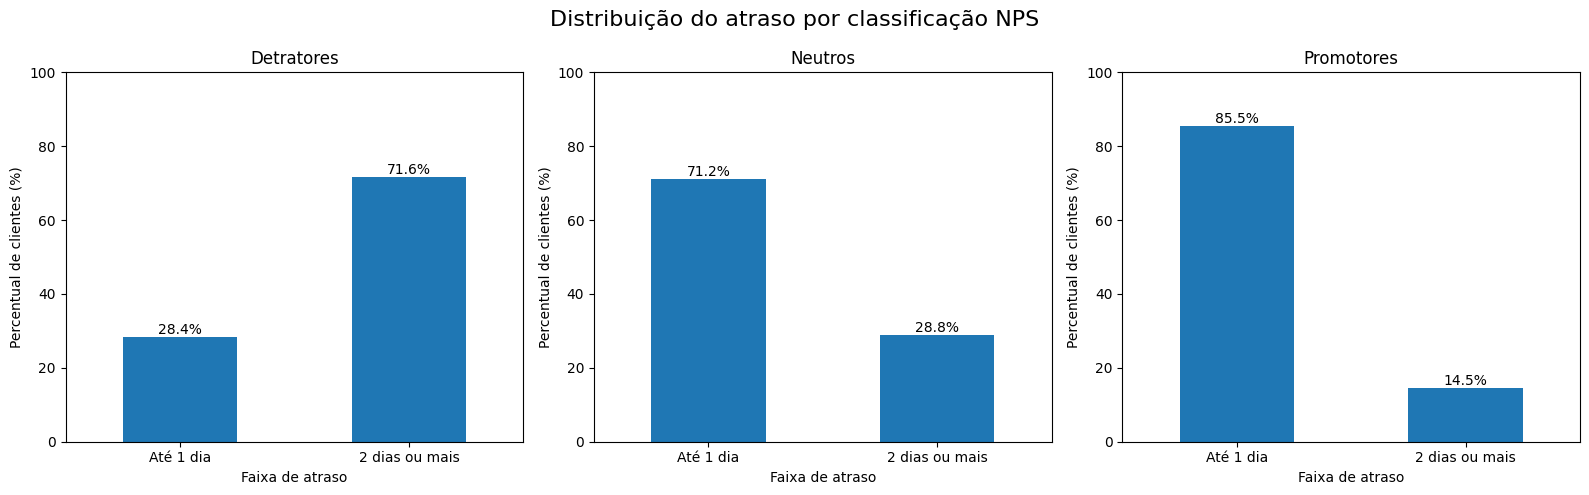

In [37]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Detratores
contagem_detratores.plot(
    kind='bar',
    ax=axs[0]
)

axs[0].set_title('Detratores')
axs[0].set_xlabel('Faixa de atraso')
axs[0].set_ylabel('Percentual de clientes (%)')
axs[0].tick_params(axis='x', rotation=0)
axs[0].set_ylim(0, 100)


# Neutros
contagem_neutros.plot(
    kind='bar',
    ax=axs[1]
)

axs[1].set_title('Neutros')
axs[1].set_xlabel('Faixa de atraso')
axs[1].set_ylabel('Percentual de clientes (%)')
axs[1].tick_params(axis='x', rotation=0)
axs[1].set_ylim(0, 100)


# Promotores
contagem_promotores.plot(
    kind='bar',
    ax=axs[2]
)

axs[2].set_title('Promotores')
axs[2].set_xlabel('Faixa de atraso')
axs[2].set_ylabel('Percentual de clientes (%)')
axs[2].tick_params(axis='x', rotation=0)
axs[2].set_ylim(0, 100)


# Rótulos em todos os gráficos
for ax in axs:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%'
        )


fig.suptitle(
    'Distribuição do atraso por classificação NPS',
    fontsize=16
)

plt.tight_layout()
plt.show()

# 2.4 Como a faixa de atraso dos detratores se relaciona com esolution_time_days, customer_service_contacts, complaints_count

### Insight — Outros fatores associados à insatisfação

Além do atraso na entrega, a análise indica que outros aspectos da jornada também apresentam diferenças relevantes entre **promotores, neutros e detratores**.

Ao comparar os valores médios entre as classificações NPS, observa-se uma piora progressiva dos indicadores conforme avançamos de promotores para detratores:

- O **tempo médio de resolução** aumenta de **3,70 dias entre promotores** para **4,62 dias entre neutros** e chega a **5,69 dias entre detratores**.
- O número médio de **contatos com o atendimento** aumenta de **0,67 entre promotores** para **1,01 entre neutros** e **1,63 entre detratores**.
- A quantidade média de **reclamações** apresenta uma diferença ainda mais expressiva: **2,27 entre promotores**, **2,69 entre neutros** e **4,44 entre detratores**.

Os resultados sugerem que a experiência detratora não está associada apenas ao desempenho da entrega. Clientes detratores também apresentam, em média, **maior tempo para resolução de problemas, maior necessidade de contato com o atendimento e maior número de reclamações**.

Esse comportamento indica a existência de **múltiplos pontos de atrito ao longo da jornada do cliente**, envolvendo tanto a operação logística quanto a experiência pós-compra e o atendimento.

> **Próxima etapa:** investigar a distribuição desses indicadores para identificar se existem **pontos de ruptura específicos** — por exemplo, a partir de quantos dias de resolução, contatos com o atendimento ou reclamações ocorre uma mudança relevante no comportamento dos clientes detratores.

In [38]:
df_detratores = df[df['clas_cliente'] == 'Detrator'].copy()

df_detratores['faixa_atraso'] = df_detratores['delivery_delay_days'].apply(
    lambda x: 'Até 1 dia' if x <= 1 else '2 dias ou mais'
)

In [39]:
df_detratores['faixa_atraso'].value_counts()

,count
faixa_atraso,
2 dias ou mais,1511
Até 1 dia,598


In [40]:
analise_detratores = (
    df_detratores
    .groupby('faixa_atraso')[
        [
            'resolution_time_days',
            'customer_service_contacts',
            'complaints_count'
        ]
    ]
    .mean()
    .round(2)
)

analise_detratores

,resolution_time_days,customer_service_contacts,complaints_count
faixa_atraso,,,
2 dias ou mais,5.54,1.55,4.47
Até 1 dia,6.08,1.83,4.37


In [41]:
analise_classes = (
    df.groupby('clas_cliente')[
        [
            'resolution_time_days',
            'customer_service_contacts',
            'complaints_count'
        ]
    ]
    .mean()
    .round(2)
)

analise_classes

,resolution_time_days,customer_service_contacts,complaints_count
clas_cliente,,,
Detrator,5.69,1.63,4.44
Neutro,4.62,1.01,2.69
Promotores,3.70,0.67,2.27


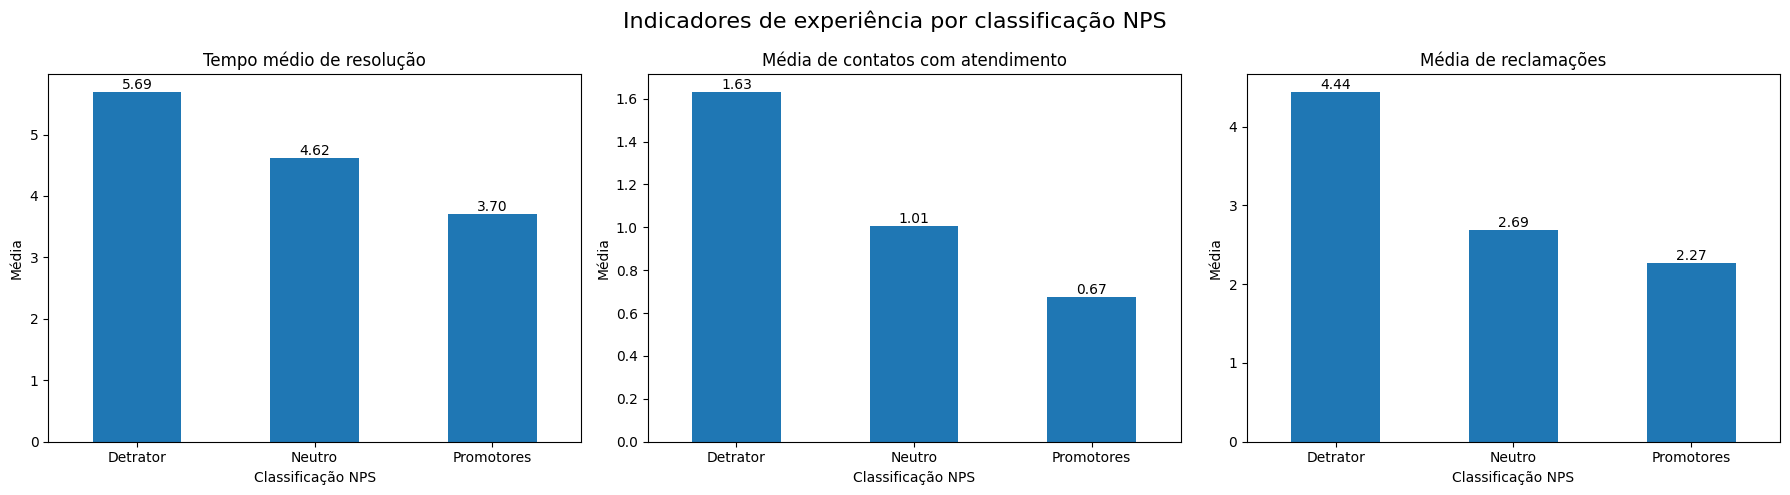

In [42]:
variaveis = [
    'resolution_time_days',
    'customer_service_contacts',
    'complaints_count'
]

titulos = [
    'Tempo médio de resolução',
    'Média de contatos com atendimento',
    'Média de reclamações'
]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, variavel in enumerate(variaveis):

    media = (
        df.groupby('clas_cliente')[variavel]
        .mean()
        .reindex(['Detrator', 'Neutro', 'Promotores'])
    )

    media.plot(
        kind='bar',
        ax=axs[i]
    )

    axs[i].set_title(titulos[i])
    axs[i].set_xlabel('Classificação NPS')
    axs[i].set_ylabel('Média')
    axs[i].tick_params(axis='x', rotation=0)

    for container in axs[i].containers:
        axs[i].bar_label(container, fmt='%.2f')

fig.suptitle(
    'Indicadores de experiência por classificação NPS',
    fontsize=16
)

plt.tight_layout()
plt.show()

# 2.5 Investigação do ponto de ruptura das variaveis: esolution_time_days, customer_service_contacts, complaints_count

### Insight — Identificação de novos pontos de ruptura

A análise da distribuição dos indicadores de atendimento e pós-venda mostra que a experiência dos clientes detratores apresenta diferenças relevantes em relação aos clientes neutros e promotores.

No **tempo de resolução**, aproximadamente **59,7% dos detratores** apresentam tempos de resolução de **5 dias ou mais**, enquanto os promotores estão mais concentrados em resoluções de até 4 dias (**67,2%**). O comportamento sugere um possível ponto crítico próximo de **5 dias**, embora a transição seja mais gradual do que nos demais indicadores.

Em relação aos **contatos com o atendimento**, observa-se uma separação mais clara. Enquanto **84,5% dos promotores** e **71,2% dos neutros** realizam no máximo um contato, entre os detratores esse percentual cai para **51,1%**. Consequentemente, **48,9% dos detratores realizam dois ou mais contatos**, contra apenas **15,5% dos promotores**, indicando **2 contatos como possível ponto de ruptura**.

O **número de reclamações apresenta uma das diferenças mais expressivas**. Aproximadamente **69,8% dos detratores possuem 4 ou mais reclamações**, enquanto **80,9% dos promotores** e **72,6% dos neutros** estão concentrados em até 3 reclamações. Dessa forma, **4 reclamações surge como um importante candidato a ponto de ruptura na experiência do cliente**.

> **Conclusão:** em conjunto com o atraso na entrega, os resultados sugerem quatro potenciais limites críticos na jornada: **2 ou mais dias de atraso, 2 ou mais contatos com atendimento, 4 ou mais reclamações e aproximadamente 5 ou mais dias para resolução**. Os padrões são especialmente fortes para atraso, contatos e reclamações, enquanto o tempo de resolução apresenta uma separação mais gradual. Esses resultados representam associações observadas na análise exploratória e não implicam, isoladamente, causalidade.

### 2.5.1. Tempo de resolução

In [43]:
ruptura_resolution = pd.crosstab(
    df['resolution_time_days'],
    df['clas_cliente'],
    normalize='columns'
).mul(100).round(1)

ruptura_resolution

clas_cliente,Detrator,Neutro,Promotores
resolution_time_days,,,
0,7.4,11.4,18.2
1,6.9,11.0,13.6
2,8.9,10.7,10.9
3,8.8,12.8,14.5
4,8.3,7.1,10.0
5,7.2,7.1,4.5
6,8.0,7.5,7.3
7,8.7,8.9,4.5
8,9.6,6.8,5.5


2.5.2. Contatos com atendimento

In [44]:
ruptura_contatos = pd.crosstab(
    df['customer_service_contacts'],
    df['clas_cliente'],
    normalize='columns'
).mul(100).round(1)

ruptura_contatos

clas_cliente,Detrator,Neutro,Promotores
customer_service_contacts,,,
0,18.6,37.4,51.8
1,32.5,33.8,32.7
2,26.9,21.0,12.7
3,13.9,6.8,1.8
4,6.1,0.7,0.9
5,1.6,0.4,0.0
6,0.3,0.0,0.0
7,0.1,0.0,0.0


2.5.3. Número de reclamações

In [45]:
ruptura_reclamacoes = pd.crosstab(
    df['complaints_count'],
    df['clas_cliente'],
    normalize='columns'
).mul(100).round(1)

ruptura_reclamacoes

clas_cliente,Detrator,Neutro,Promotores
complaints_count,,,
0,0.2,3.6,8.2
1,1.8,21.0,23.6
2,8.6,23.1,28.2
3,19.6,24.9,20.9
4,25.6,15.7,15.5
5,19.9,7.5,2.7
6,12.3,2.5,0.0
7,7.8,1.8,0.0
8,3.0,0.0,0.0


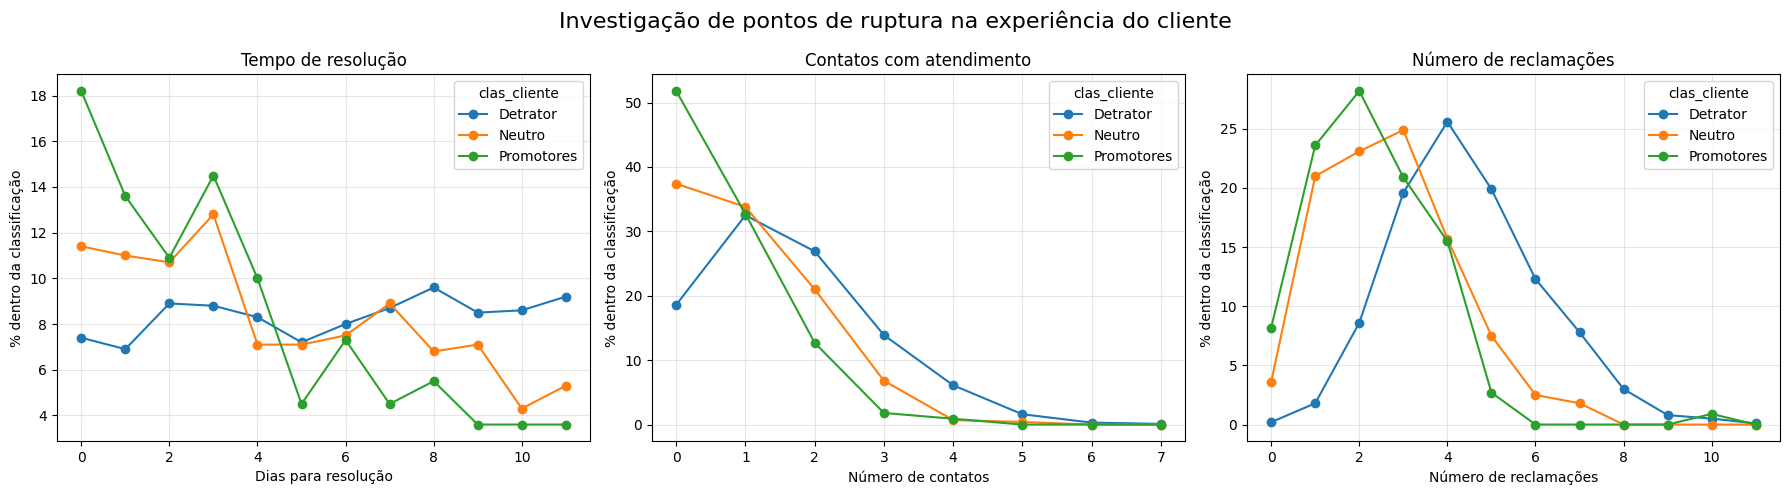

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))


# Tempo de resolução
ruptura_resolution.plot(
    kind='line',
    marker='o',
    ax=axs[0]
)

axs[0].set_title('Tempo de resolução')
axs[0].set_xlabel('Dias para resolução')
axs[0].set_ylabel('% dentro da classificação')
axs[0].grid(alpha=0.3)


# Contatos com atendimento
ruptura_contatos.plot(
    kind='line',
    marker='o',
    ax=axs[1]
)

axs[1].set_title('Contatos com atendimento')
axs[1].set_xlabel('Número de contatos')
axs[1].set_ylabel('% dentro da classificação')
axs[1].grid(alpha=0.3)


# Reclamações
ruptura_reclamacoes.plot(
    kind='line',
    marker='o',
    ax=axs[2]
)

axs[2].set_title('Número de reclamações')
axs[2].set_xlabel('Número de reclamações')
axs[2].set_ylabel('% dentro da classificação')
axs[2].grid(alpha=0.3)


fig.suptitle(
    'Investigação de pontos de ruptura na experiência do cliente',
    fontsize=16
)

plt.tight_layout()
plt.show()

# 3. Dado determinado nível de atraso, reclamações, contatos ou tempo de resolução, qual é a proporção de detratores?

## 3.1 Numero de reclamaçoes

### Ponto de ruptura — Número de reclamações

A análise da proporção de detratores por quantidade de reclamações apresenta uma relação clara entre o aumento das reclamações e a deterioração da experiência do cliente.

A proporção de detratores cresce progressivamente de **17,4% entre clientes sem reclamações** para **30,3% com uma reclamação**, **65,3% com duas** e **81,7% com três reclamações**.

Considerando que a proporção geral de detratores na base é de **84,36%**, observa-se que **4 reclamações representam um possível ponto de ruptura**: nesse nível, a incidência de detratores atinge **89,8%**, superando o baseline da base em **5,4 pontos percentuais**. A partir desse ponto, a proporção permanece elevada, chegando a **94,6% com 5 reclamações** e **97,4% com 6 reclamações**.

Além disso, o crescimento de **30,3% para 65,3% entre uma e duas reclamações** sugere que o segundo contato de reclamação já pode funcionar como um importante **sinal de alerta**, mesmo antes do limite crítico identificado.

> **Insight de negócio:** clientes que acumulam reclamações apresentam uma associação progressivamente maior com a condição de detrator. Dessa forma, **2 reclamações podem ser utilizadas como sinal de alerta para atuação preventiva**, enquanto **4 ou mais reclamações caracterizam um estágio crítico da experiência**, no qual a incidência de detratores já supera o comportamento médio da base.

In [47]:
ruptura_reclamacoes_2 = pd.crosstab(
    df['complaints_count'],
    df['clas_cliente'],
    normalize='index'
).mul(100).round(1)

ruptura_reclamacoes_2

clas_cliente,Detrator,Neutro,Promotores
complaints_count,,,
0,17.4,43.5,39.1
1,30.3,48.4,21.3
2,65.3,23.5,11.2
3,81.7,13.8,4.5
4,89.8,7.3,2.8
5,94.6,4.7,0.7
6,97.4,2.6,0.0
7,97.0,3.0,0.0
8,100.0,0.0,0.0


In [48]:
baseline_detratores = (
    df['clas_cliente']
    .eq('Detrator')
    .mean()
    * 100
)

baseline_detratores

np.float64(84.36)

In [49]:
ruptura_reclamacoes_2['baseline_detratores'] = baseline_detratores

ruptura_reclamacoes_2['dif_baseline'] = (
    ruptura_reclamacoes_2['Detrator']
    - baseline_detratores
).round(1)

ruptura_reclamacoes_2

clas_cliente,Detrator,Neutro,Promotores,baseline_detratores,dif_baseline
complaints_count,,,,,
0,17.4,43.5,39.1,84.36,-67.0
1,30.3,48.4,21.3,84.36,-54.1
2,65.3,23.5,11.2,84.36,-19.1
3,81.7,13.8,4.5,84.36,-2.7
4,89.8,7.3,2.8,84.36,5.4
5,94.6,4.7,0.7,84.36,10.2
6,97.4,2.6,0.0,84.36,13.0
7,97.0,3.0,0.0,84.36,12.6
8,100.0,0.0,0.0,84.36,15.6


3.2 customer_service_contacts

In [50]:
# Proporção das classificações para cada número de contatos
ruptura_contatos_2 = pd.crosstab(
    df['customer_service_contacts'],
    df['clas_cliente'],
    normalize='index'
).mul(100).round(1)

# Baseline geral de detratores
baseline_detratores = (
    df['clas_cliente']
    .eq('Detrator')
    .mean()
    * 100
)

# Adicionando baseline
ruptura_contatos_2['baseline_detratores'] = baseline_detratores

# Diferença em relação ao baseline
ruptura_contatos_2['dif_baseline'] = (
    ruptura_contatos_2['Detrator']
    - baseline_detratores
).round(1)

ruptura_contatos_2

clas_cliente,Detrator,Neutro,Promotores,baseline_detratores,dif_baseline
customer_service_contacts,,,,,
0,70.8,19.0,10.3,84.36,-13.6
1,83.9,11.6,4.4,84.36,-0.5
2,88.6,9.2,2.2,84.36,4.2
3,93.3,6.1,0.6,84.36,8.9
4,97.7,1.5,0.8,84.36,13.3
5,97.1,2.9,0.0,84.36,12.7
6,100.0,0.0,0.0,84.36,15.6
7,100.0,0.0,0.0,84.36,15.6


In [51]:
ruptura_resolution_2 = pd.crosstab(
    df['resolution_time_days'],
    df['clas_cliente'],
    normalize='index'
).mul(100).round(1)

ruptura_resolution_2['baseline_detratores'] = baseline_detratores

ruptura_resolution_2['dif_baseline'] = (
    ruptura_resolution_2['Detrator']
    - baseline_detratores
).round(1)

ruptura_resolution_2

clas_cliente,Detrator,Neutro,Promotores,baseline_detratores,dif_baseline
resolution_time_days,,,,,
0,75.0,15.4,9.6,84.36,-9.4
1,76.0,16.1,7.8,84.36,-8.4
2,81.7,13.1,5.2,84.36,-2.7
3,78.1,15.2,6.8,84.36,-6.3
4,85.0,9.7,5.3,84.36,0.6
5,85.8,11.4,2.8,84.36,1.4
6,85.3,10.7,4.1,84.36,0.9
7,85.9,11.7,2.3,84.36,1.5
8,89.0,8.4,2.6,84.36,4.6


In [52]:
ruptura_atraso_2 = pd.crosstab(
    df['delivery_delay_days'],
    df['clas_cliente'],
    normalize='index'
).mul(100).round(1)

ruptura_atraso_2['baseline_detratores'] = baseline_detratores

ruptura_atraso_2['dif_baseline'] = (
    ruptura_atraso_2['Detrator']
    - baseline_detratores
).round(1)

ruptura_atraso_2

clas_cliente,Detrator,Neutro,Promotores,baseline_detratores,dif_baseline
delivery_delay_days,,,,,
0,51.6,30.3,18.1,84.36,-32.8
1,74.0,18.9,7.2,84.36,-10.4
2,87.9,10.1,2.0,84.36,3.5
3,96.8,2.7,0.6,84.36,12.4
4,99.3,0.7,0.0,84.36,14.9
5,100.0,0.0,0.0,84.36,15.6
6,100.0,0.0,0.0,84.36,15.6
7,100.0,0.0,0.0,84.36,15.6
8,100.0,0.0,0.0,84.36,15.6


3.3 score de acúmulo de atritos

### Efeito acumulado dos pontos críticos na experiência do cliente

Após identificar pontos críticos individuais relacionados ao atraso na entrega, atendimento, reclamações e tempo de resolução, foi analisado o efeito do **acúmulo desses fatores na experiência do cliente**.

Para cada cliente, foi contabilizada a quantidade de condições críticas presentes em sua jornada:

- **Atraso na entrega:** 2 dias ou mais;
- **Contatos com atendimento:** 2 ou mais contatos;
- **Reclamações:** 4 ou mais;
- **Tempo de resolução:** 4 dias ou mais.

Os resultados mostram uma relação progressiva entre o número de pontos críticos acumulados e a proporção de detratores:

- **0 pontos críticos:** 35,4% de detratores;
- **1 ponto crítico:** 63,4%;
- **2 pontos críticos:** 86,0%;
- **3 pontos críticos:** 95,5%;
- **4 pontos críticos:** 98,7%.

A presença de apenas **um ponto crítico** já está associada a um aumento de **28,0 pontos percentuais** na proporção de detratores em comparação aos clientes sem pontos críticos.

Com **dois pontos críticos simultâneos**, a proporção de detratores alcança **86,0%**, superando inclusive o baseline geral da base, de aproximadamente **84,4%**.

Nos casos mais extremos, quando o cliente apresenta **três ou quatro pontos críticos**, a incidência de detratores chega a **95,5% e 98,7%**, respectivamente.

> **Insight de negócio:** os resultados sugerem que a insatisfação não está associada apenas a uma falha isolada, mas principalmente ao **acúmulo de atritos ao longo da jornada**. Quanto maior o número de pontos críticos enfrentados pelo cliente, maior a incidência de detratores.

> Isso indica uma oportunidade de atuação preventiva: clientes que atingem **dois pontos críticos simultaneamente** podem ser considerados um grupo de alto risco de insatisfação, permitindo que a empresa priorize ações antes que novos problemas sejam acumulados.### Efeito acumulado dos pontos críticos na experiência do cliente

Após identificar pontos críticos individuais relacionados ao atraso na entrega, atendimento, reclamações e tempo de resolução, foi analisado o efeito do **acúmulo desses fatores na experiência do cliente**.

Para cada cliente, foi contabilizada a quantidade de condições críticas presentes em sua jornada:

- **Atraso na entrega:** 2 dias ou mais;
- **Contatos com atendimento:** 2 ou mais contatos;
- **Reclamações:** 4 ou mais;
- **Tempo de resolução:** 4 dias ou mais.

Os resultados mostram uma relação progressiva entre o número de pontos críticos acumulados e a proporção de detratores:

- **0 pontos críticos:** 35,4% de detratores;
- **1 ponto crítico:** 63,4%;
- **2 pontos críticos:** 86,0%;
- **3 pontos críticos:** 95,5%;
- **4 pontos críticos:** 98,7%.

A presença de apenas **um ponto crítico** já está associada a um aumento de **28,0 pontos percentuais** na proporção de detratores em comparação aos clientes sem pontos críticos.

Com **dois pontos críticos simultâneos**, a proporção de detratores alcança **86,0%**, superando inclusive o baseline geral da base, de aproximadamente **84,4%**.

Nos casos mais extremos, quando o cliente apresenta **três ou quatro pontos críticos**, a incidência de detratores chega a **95,5% e 98,7%**, respectivamente.

> **Insight de negócio:** os resultados sugerem que a insatisfação não está associada apenas a uma falha isolada, mas principalmente ao **acúmulo de atritos ao longo da jornada**. Quanto maior o número de pontos críticos enfrentados pelo cliente, maior a incidência de detratores.

> Isso indica uma oportunidade de atuação preventiva: clientes que atingem **dois pontos críticos simultaneamente** podem ser considerados um grupo de alto risco de insatisfação, permitindo que a empresa priorize ações antes que novos problemas sejam acumulados.

In [53]:
# Criando indicadores para cada ponto crítico

df['critico_atraso'] = (
    df['delivery_delay_days'] >= 2
).astype(int)

df['critico_contatos'] = (
    df['customer_service_contacts'] >= 2
).astype(int)

df['critico_reclamacoes'] = (
    df['complaints_count'] >= 4
).astype(int)

df['critico_resolucao'] = (
    df['resolution_time_days'] >= 4
).astype(int)


# Somando quantos pontos críticos cada cliente apresentou

df['qtd_pontos_criticos'] = (
    df['critico_atraso']
    + df['critico_contatos']
    + df['critico_reclamacoes']
    + df['critico_resolucao']
)

df[[
    'critico_atraso',
    'critico_contatos',
    'critico_reclamacoes',
    'critico_resolucao',
    'qtd_pontos_criticos',
    'clas_cliente'
]].head(10)

,critico_atraso,critico_contatos,critico_reclamacoes,critico_resolucao,qtd_pontos_criticos,clas_cliente
0,1,0,0,1,2,Detrator
1,1,0,0,1,2,Detrator
2,0,1,1,1,3,Detrator
3,1,0,1,1,3,Detrator
4,0,0,0,0,0,Detrator
5,1,1,1,0,3,Detrator
6,1,1,1,1,4,Detrator
7,1,0,0,0,1,Detrator
8,1,0,0,1,2,Detrator
9,1,0,0,1,2,Detrator


In [54]:
acumulo_atritos = pd.crosstab(
    df['qtd_pontos_criticos'],
    df['clas_cliente'],
    normalize='index'
).mul(100).round(1)

acumulo_atritos

clas_cliente,Detrator,Neutro,Promotores
qtd_pontos_criticos,,,
0,35.4,33.9,30.7
1,63.4,26.1,10.5
2,86.0,11.9,2.1
3,95.5,3.7,0.8
4,98.7,1.1,0.2


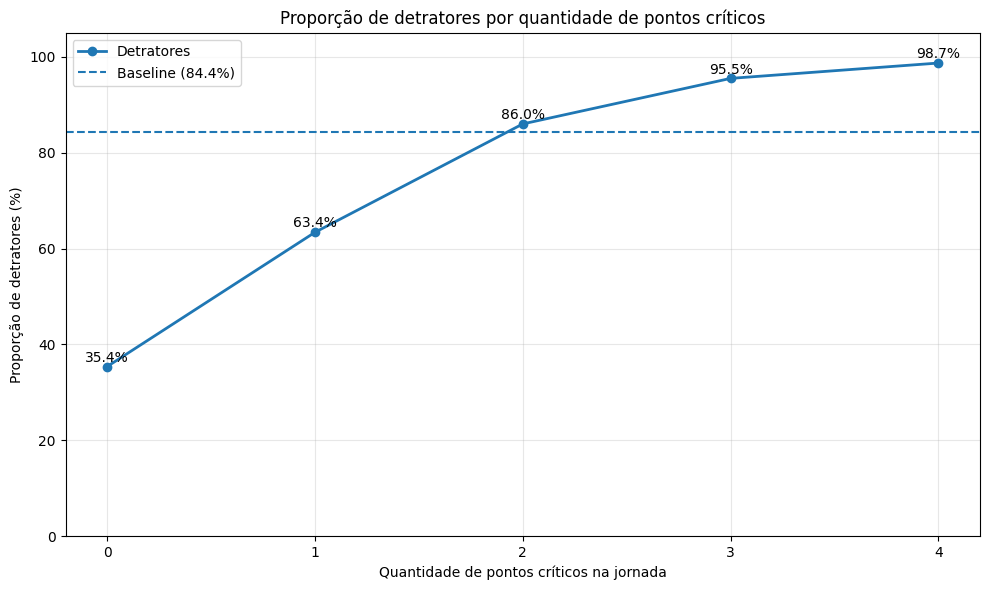

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    acumulo_atritos.index,
    acumulo_atritos['Detrator'],
    marker='o',
    linewidth=2,
    label='Detratores'
)

# Linha do baseline
ax.axhline(
    y=baseline_detratores,
    linestyle='--',
    label=f'Baseline ({baseline_detratores:.1f}%)'
)

# Rótulos dos pontos
for x, y in zip(
    acumulo_atritos.index,
    acumulo_atritos['Detrator']
):
    ax.text(
        x,
        y + 1,
        f'{y:.1f}%',
        ha='center'
    )

ax.set_title(
    'Proporção de detratores por quantidade de pontos críticos'
)

ax.set_xlabel(
    'Quantidade de pontos críticos na jornada'
)

ax.set_ylabel(
    'Proporção de detratores (%)'
)

ax.set_xticks(acumulo_atritos.index)

ax.set_ylim(0, 105)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Existe algum problema na Operação que está causando as entregas?

### 4.1 Análise regional dos atrasos de entrega

A análise regional indica que o atraso nas entregas apresenta um comportamento **consistente em todo o território analisado**.

O atraso médio varia apenas entre **2,14 e 2,22 dias** entre as regiões, enquanto a média geral da operação é de **2,19 dias**. Além disso, a distribuição dos atrasos apresenta comportamento bastante semelhante entre as regiões, com mediana próxima de **2 dias**.

Essa baixa variação indica que **não há evidências de uma região específica sendo responsável pelo problema de atraso**. O comportamento ocorre de maneira generalizada, sugerindo que sua origem pode estar associada ao próprio processo logístico da empresa.

Esse resultado ganha relevância quando relacionado às análises anteriores, nas quais **2 dias de atraso foram identificados como um ponto crítico na experiência do cliente**.

> **Insight de negócio:** a operação apresenta um atraso típico próximo justamente da faixa que anteriormente demonstrou forte associação com a geração de detratores. Como esse comportamento é observado de forma semelhante em todas as regiões, os dados sugerem um possível **gargalo estrutural na operação logística**, em vez de um problema regional isolado.

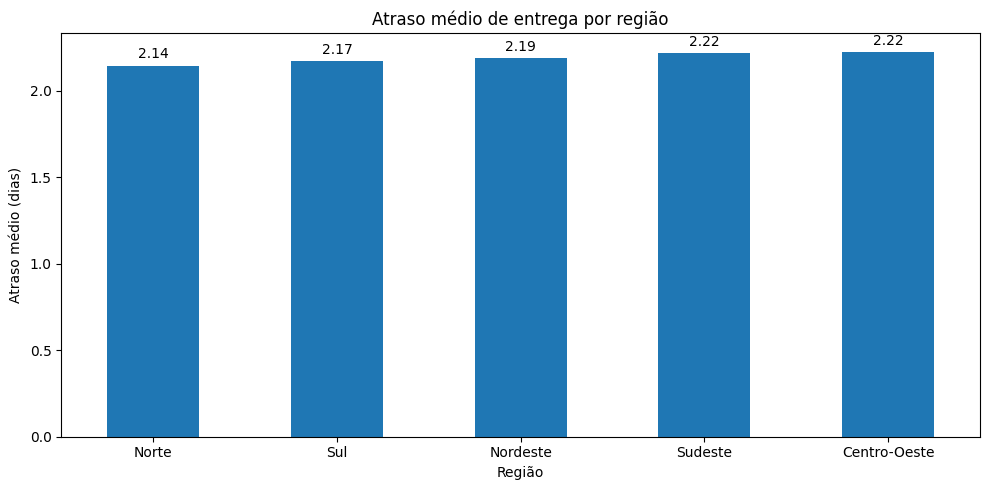

In [56]:
# Calculando o atraso médio por região
atraso_regiao = (
    df.groupby('customer_region')['delivery_delay_days']
      .mean()
      .sort_values()
)

# Criando o gráfico
fig, ax = plt.subplots(figsize=(10, 5))

atraso_regiao.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Atraso médio de entrega por região')
ax.set_xlabel('Região')
ax.set_ylabel('Atraso médio (dias)')

ax.tick_params(axis='x', rotation=0)

# Rótulos nas barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

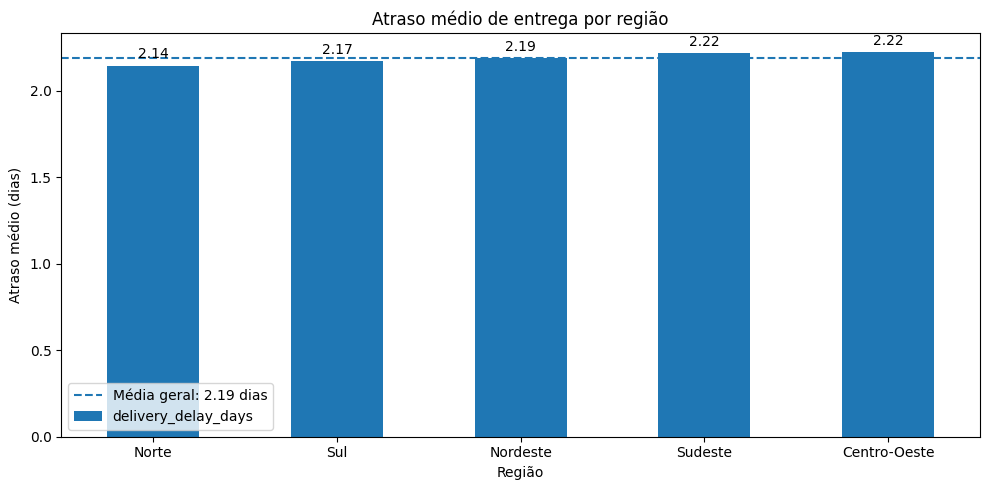

In [57]:
# Calculando o atraso médio por região
atraso_regiao = (
    df.groupby('customer_region')['delivery_delay_days']
      .mean()
      .sort_values()
)

# Média geral
media_geral = df['delivery_delay_days'].mean()

# Criando o gráfico
fig, ax = plt.subplots(figsize=(10, 5))

atraso_regiao.plot(
    kind='bar',
    ax=ax
)

# Linha da média geral
ax.axhline(
    y=media_geral,
    linestyle='--',
    label=f'Média geral: {media_geral:.2f} dias'
)

ax.set_title('Atraso médio de entrega por região')
ax.set_xlabel('Região')
ax.set_ylabel('Atraso médio (dias)')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

ax.legend()

plt.tight_layout()
plt.show()

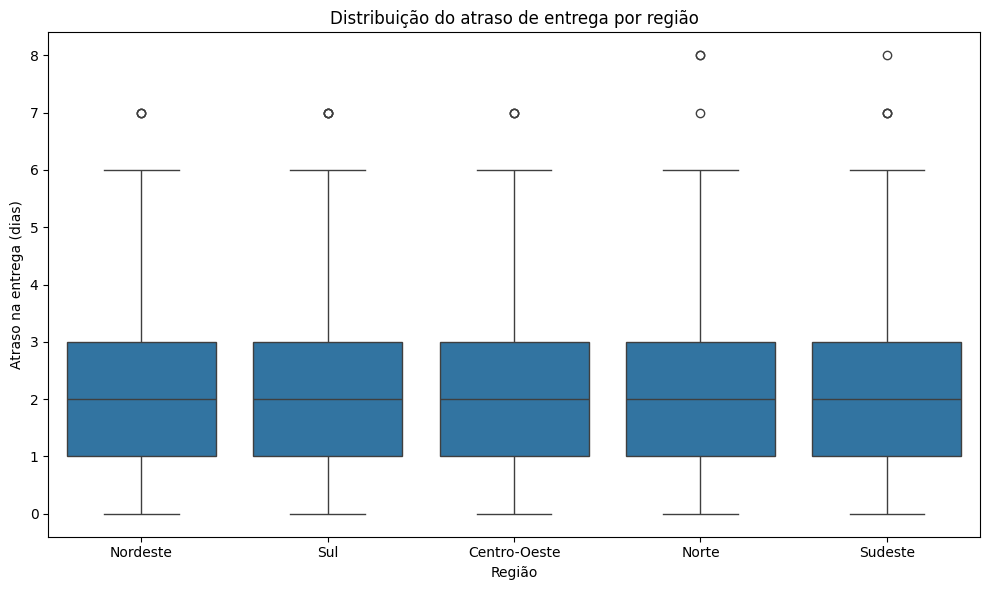

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='customer_region',
    y='delivery_delay_days',
    ax=ax
)

ax.set_title('Distribuição do atraso de entrega por região')
ax.set_xlabel('Região')
ax.set_ylabel('Atraso na entrega (dias)')

ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

4.2 Tentativas de entrega × atraso

In [59]:
# Atraso médio por número de tentativas de entrega
atraso_tentativas = (
    df.groupby('delivery_attempts')['delivery_delay_days']
      .mean()
      .round(2)
)

atraso_tentativas

,delivery_delay_days
delivery_attempts,
1,2.15
2,2.25
3,2.16


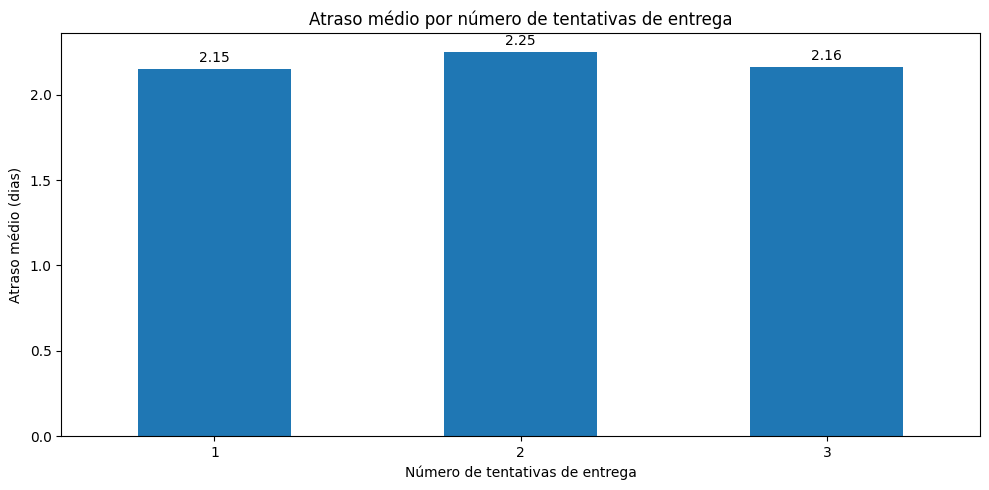

In [60]:
fig, ax = plt.subplots(figsize=(10, 5))

atraso_tentativas.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Atraso médio por número de tentativas de entrega')
ax.set_xlabel('Número de tentativas de entrega')
ax.set_ylabel('Atraso médio (dias)')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

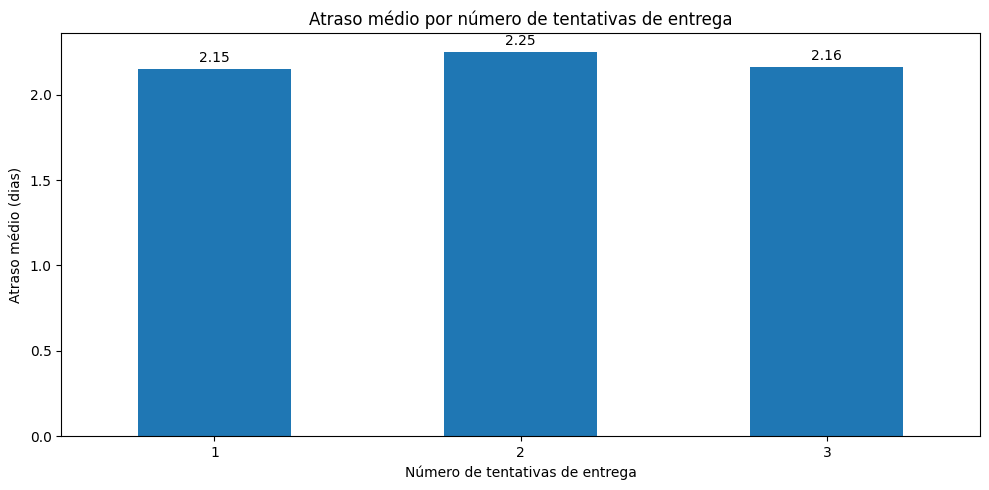

In [61]:
fig, ax = plt.subplots(figsize=(10, 5))

atraso_tentativas.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Atraso médio por número de tentativas de entrega')
ax.set_xlabel('Número de tentativas de entrega')
ax.set_ylabel('Atraso médio (dias)')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

4.3 Tentativas de entrega × classificação NP

In [62]:
tentativas_nps = (
    df.groupby('clas_cliente')['delivery_attempts']
      .mean()
      .round(2)
)

tentativas_nps

,delivery_attempts
clas_cliente,
Detrator,2.00
Neutro,2.01
Promotores,2.15


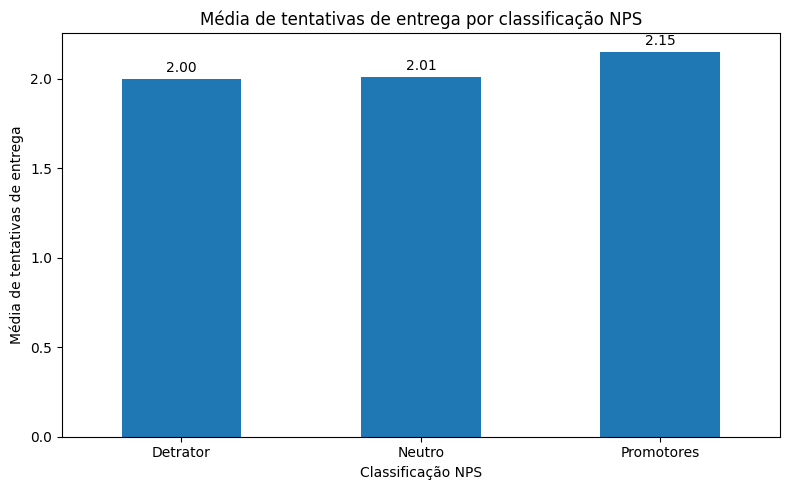

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))

tentativas_nps.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Média de tentativas de entrega por classificação NPS')
ax.set_xlabel('Classificação NPS')
ax.set_ylabel('Média de tentativas de entrega')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

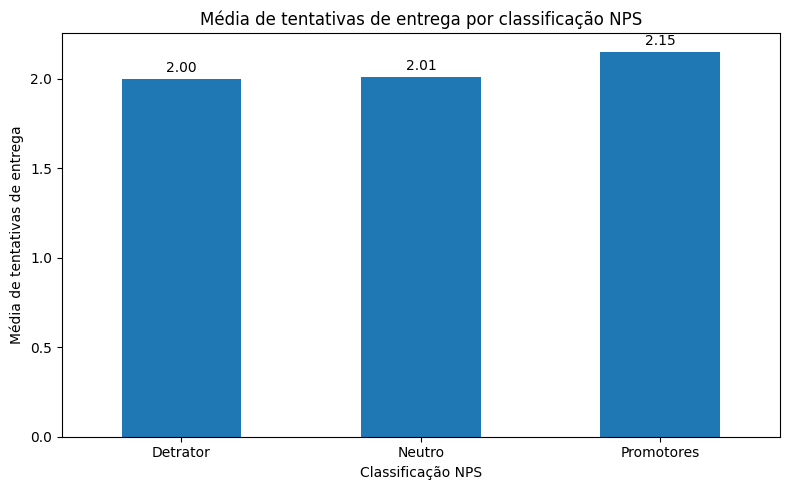

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

tentativas_nps.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Média de tentativas de entrega por classificação NPS')
ax.set_xlabel('Classificação NPS')
ax.set_ylabel('Média de tentativas de entrega')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

4.4 Frete X Atraso

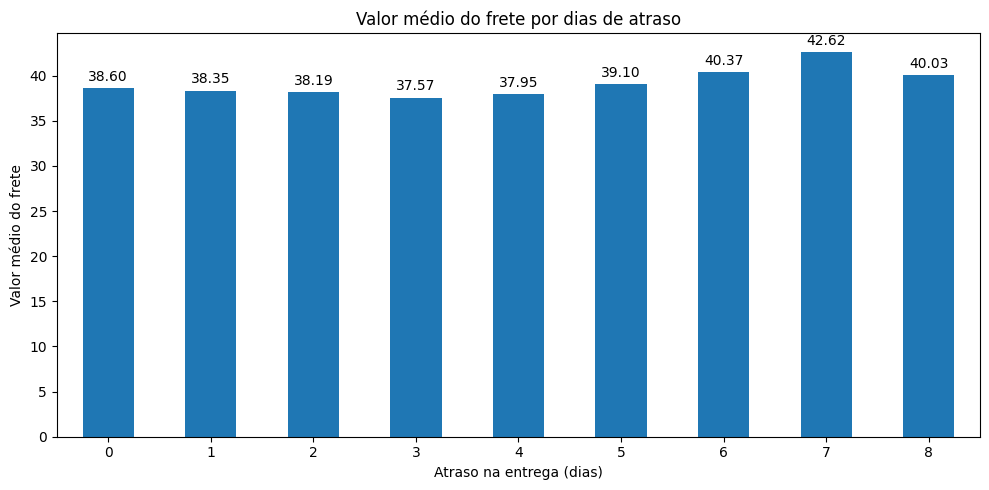

In [65]:
frete_atraso = (
    df.groupby('delivery_delay_days')['freight_value']
      .mean()
      .round(2)
)

fig, ax = plt.subplots(figsize=(10, 5))

frete_atraso.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Valor médio do frete por dias de atraso')
ax.set_xlabel('Atraso na entrega (dias)')
ax.set_ylabel('Valor médio do frete')

ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3
    )

plt.tight_layout()
plt.show()

### 4.2 Investigação de possíveis fatores associados ao atraso

Após identificar que o atraso médio de entrega apresenta comportamento semelhante entre as diferentes regiões, foram analisadas outras variáveis relacionadas ao processo logístico com o objetivo de identificar possíveis fatores associados aos atrasos.

#### Tentativas de entrega

O número de tentativas de entrega não apresentou uma relação relevante com o atraso. O atraso médio permaneceu próximo de 2 dias independentemente da quantidade de tentativas realizadas:

- 1 tentativa: **2,15 dias**
- 2 tentativas: **2,25 dias**
- 3 tentativas: **2,16 dias**

Além disso, a média de tentativas também apresentou pouca diferença entre as classificações de NPS. Detratores e neutros apresentam aproximadamente **2 tentativas**, enquanto promotores apresentam média de **2,15 tentativas**.

Dessa forma, não há evidências de que múltiplas tentativas de entrega sejam responsáveis pelo maior nível de atraso observado entre os clientes detratores.

#### Valor do frete

O valor médio do frete também não apresentou uma relação clara com o aumento do atraso. Entre entregas sem atraso e entregas com até 5 dias de atraso, o valor médio permanece relativamente estável.

Embora sejam observados valores ligeiramente maiores em atrasos mais elevados, o comportamento não apresenta uma tendência suficientemente consistente para indicar o valor do frete como principal fator associado ao atraso.

### Insight

As análises realizadas até o momento indicam que o atraso de entrega possui forte relação com a experiência negativa do cliente, porém sua ocorrência não parece ser explicada pela região, pelo número de tentativas de entrega ou pelo valor do frete.

O fato de o atraso apresentar comportamento semelhante entre regiões e diferentes condições de entrega sugere que o problema pode estar associado a uma etapa mais ampla do processo logístico, comum às diferentes operações.

Entretanto, com as variáveis disponíveis no dataset, não é possível determinar a causa operacional do atraso. Para identificar sua origem seriam necessárias informações adicionais sobre etapas como preparação do pedido, expedição, transportadora, centro de distribuição e prazo previsto de entrega.

# 5. Conclusão

A análise exploratória teve como objetivo compreender os principais fatores associados à satisfação dos clientes e identificar possíveis **pontos de ruptura na jornada de compra**.

Os resultados indicam que a insatisfação não está relacionada a um único fator, mas ao **acúmulo de diferentes atritos ao longo da experiência do cliente**, principalmente relacionados à entrega e ao atendimento pós-compra.

## Principais fatores associados aos detratores

A comparação entre **promotores, neutros e detratores** mostrou que os detratores apresentam, em média:

- maior atraso na entrega;
- maior tempo para resolução de problemas;
- maior número de contatos com o atendimento;
- maior quantidade de reclamações.

A investigação desses indicadores permitiu identificar possíveis limites críticos na experiência:

| Indicador | Ponto crítico identificado |
|---|---:|
| Atraso na entrega | **2 dias ou mais** |
| Contatos com atendimento | **2 contatos ou mais** |
| Reclamações | **4 reclamações ou mais** |
| Tempo de resolução | **4 dias ou mais** |

Entre esses fatores, **atraso na entrega e quantidade de reclamações apresentaram alguns dos padrões mais evidentes de deterioração da experiência**.

## O acúmulo de problemas é ainda mais relevante

Ao analisar os pontos críticos em conjunto, foi identificado um comportamento progressivo na proporção de detratores:

- **0 pontos críticos:** 35,4% de detratores;
- **1 ponto crítico:** 63,4%;
- **2 pontos críticos:** 86,0%;
- **3 pontos críticos:** 95,5%;
- **4 pontos críticos:** 98,7%.

Esse resultado sugere que a insatisfação está fortemente associada ao **acúmulo de atritos na jornada**. Uma ocorrência isolada pode não determinar uma experiência negativa, porém, conforme diferentes problemas se acumulam, a presença de clientes detratores aumenta de forma significativa.

Dessa forma, clientes que apresentam **dois ou mais pontos críticos simultaneamente** podem representar um grupo relevante para ações preventivas e de recuperação da experiência.

## Logística como principal ponto de atenção

A análise do atraso também revelou um possível problema estrutural na operação logística.

O atraso médio das entregas permanece próximo de **2 dias em todas as regiões analisadas**, com pouca variação regional. Além disso, a distribuição dos atrasos apresenta comportamento semelhante entre as regiões.

Esse resultado é especialmente relevante porque **2 dias de atraso também foram identificados como um ponto crítico para a satisfação dos clientes**.

A investigação de outras variáveis logísticas disponíveis, como **número de tentativas de entrega e valor do frete**, não apresentou evidências suficientes para explicar esse comportamento. Dessa forma, os dados sugerem que o atraso pode estar relacionado a alguma etapa mais ampla do processo logístico, comum às diferentes regiões.

Com as informações disponíveis, entretanto, **não é possível determinar exatamente onde o atraso está sendo gerado**.

## Recomendações de negócio

A partir dos resultados encontrados, as principais oportunidades identificadas são:

1. **Priorizar a redução dos atrasos de entrega**, principalmente evitando que ultrapassem 2 dias.
2. **Criar alertas para clientes que acumulam pontos críticos**, permitindo atuação preventiva antes da deterioração completa da experiência.
3. **Monitorar clientes com recorrência de contatos e reclamações**, principalmente quando ultrapassarem os limites identificados.
4. **Aprofundar a investigação do processo logístico**, incorporando informações como transportadora, centro de distribuição, rota, prazo prometido, tempo de separação e expedição.
5. Utilizar os pontos críticos identificados como indicadores de acompanhamento da experiência, complementando o próprio NPS.

> ### Conclusão final
>
> Os dados indicam que a baixa satisfação dos clientes está associada principalmente à **combinação de falhas logísticas e atritos no atendimento pós-compra**. O atraso de entrega aparece como um dos principais pontos de atenção, especialmente porque o nível médio observado na operação está próximo do limite identificado como crítico para a experiência.
>
> Mais do que tratar cada problema isoladamente, os resultados mostram a importância de identificar clientes que começam a **acumular atritos ao longo da jornada**. A atuação preventiva sobre esses clientes pode representar uma oportunidade relevante para reduzir a geração de detratores e melhorar a experiência geral.
>
> Por se tratar de uma análise exploratória, os resultados demonstram **associações entre as variáveis e o NPS, e não relações de causalidade**. Análises adicionais e novas variáveis operacionais seriam necessárias para determinar as causas dos problemas identificados e mensurar o impacto das ações propostas.